# eBPF Bottleneck Classifier v5 — Imbalance Handling, Feature Validation & Medium-Class Investigation

**Built on the v4 results:** Accuracy ≈ 69%, Weighted F1 ≈ 0.70, Macro F1 ≈ 0.63 (Random Forest / LightGBM, leakage-free feature set, dynamic percentile labels).

This notebook does **not** repeat full EDA. It picks up exactly where the v4 review left off and runs the four
highest-priority follow-ups in order:

| Section | Addresses |
|---|---|
| 1 | Rebuild the leakage-free feature set (carried over from v4, condensed) |
| 2 | Stratified train/test split |
| 3 | **Class imbalance**: baseline vs `class_weight='balanced'` vs SMOTE vs Borderline-SMOTE vs ADASYN |
| 4 | **Feature scaling** with `StandardScaler` (fit on train only) + a neural model (MLP) comparison |
| 5 | **Feature importance**: RF impurity importance vs permutation importance vs SHAP |
| 6 | **Confusion matrix + misclassified-sample inspection** for the champion model |
| 7 | **Medium-class overlap investigation**: class-wise distributions of the diagnostic (non-feature) stall columns |
| 8 | Final comparison table, champion selection, and artifact saving |

**Rules enforced throughout (per the v4 review's "Avoid" list):**
- Resampling (SMOTE/ADASYN/etc.) is fit **only** on `X_train`/`y_train`, never on the test set.
- `StandardScaler` is fit **only** on `X_train`, then applied to `X_test` — no whole-dataset normalization.
- No features are dropped on the basis of Pearson correlation alone; importance is triangulated across three
  independent methods (impurity, permutation, SHAP) before any feature is treated as unimportant.
- Evaluation always reports **Macro F1** and **per-class recall/precision**, not just accuracy.

---
# Section 1 — Load & Rebuild the Leakage-Free Feature Set
Condensed from v4 Sections 1–4. If you already have `df` with `FEATURE_COLS` in memory from v4, you can skip to Section 2.

In [3]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_fscore_support, f1_score, accuracy_score
)

pd.set_option('display.float_format', '{:.3f}'.format)
pd.set_option('display.max_columns', 60)
sns.set_style('whitegrid')

RANDOM_STATE = 42

In [5]:
# ── Load multiple CSV parts (manually named, no auto-discovery) ──────────────
CSV_PARTS = [
    'perf_metrics.csv',
    'perf_metrics1.csv',
    'perf_metrics2.csv',
    # add more here as you collect them
]
# ──────────────────────────────────────────────────────────────────────────────

dfs = []
for path in CSV_PARTS:
    if not os.path.exists(path):
        print(f"  skipping (not found): {path}")
        continue
    part = pd.read_csv(path)
    part['source_file'] = path
    dfs.append(part)
    print(f"  loaded {path:<20}: {len(part):>8} rows")

df_raw = pd.concat(dfs, ignore_index=True)
print(f"\nCombined shape: {df_raw.shape}")
print(f"Sessions found : {df_raw['session_label'].unique().tolist()}")
df_raw['session_label'].value_counts()

  loaded perf_metrics.csv    :   526895 rows
  skipping (not found): perf_metrics1.csv
  skipping (not found): perf_metrics2.csv

Combined shape: (526895, 45)
Sessions found : ['idle', 'cpu_low', 'cpu_medium', 'cpu_high', 'cpu_overloaded', 'mem_low', 'mem_high', 'io_low', 'lock_low', 'mixed_load', 'cpu_extreme', 'cpu_ultra', 'mem_extreme', 'mem_thrashing', 'cpu_mem_extreme', 'cpu_mem_ultra', 'io_extreme', 'cpu_io_extreme', 'lock_extreme', 'lock_cpu_mix', 'everything_max', 'everything_insane', 'cpu_2x', 'cpu_4x', 'cpu_8x', 'mem_reclaim', 'mem_heavy_reclaim', 'cpu_mem_2x', 'cpu_mem_4x', 'cpu_mem_8x', 'cpu_mem_io', 'cpu_mem_io_heavy', 'lock_heavy', 'lock_cpu_heavy', 'everything_extreme', 'compile_only', 'compile_sysbench', 'compile_blender', 'full_system', 'mem_swap_thrashing', 'cpu_l3_cache_misses', 'mem_swap_thrash', 'mem_tlb_cache_miss', 'io_async_saturation', 'ctx_flood', 'llm_inference', 'ml_training', 'stream_memory_contention', 'cache_contention', 'context_switch_contention']


session_label
stream_memory_contention     59350
context_switch_contention    45920
cache_contention             45859
llm_inference                39621
everything_max               21993
ml_training                  21422
everything_insane            20568
lock_cpu_heavy               11752
cpu_8x                       10213
lock_low                     10112
lock_heavy                    9933
everything_extreme            9705
cpu_mem_io                    9449
cpu_medium                    9261
full_system                   8964
cpu_low                       8331
cpu_mem_io_heavy              8082
cpu_mem_4x                    8024
cpu_mem_8x                    7969
mem_low                       7914
mem_extreme                   7764
mem_reclaim                   7449
compile_only                  6823
cpu_mem_2x                    6718
io_low                        6653
compile_sysbench              6585
compile_blender               6570
mem_tlb_cache_miss            6457
io_ext

In [4]:
# ── CLEANING (same rules as v4) ───────────────────────────────────────────────
df = df_raw.copy()
before = len(df)

df = df[df['pid'] > 0]
df = df[df['ctx_switches'] > 0]
df = df[df['latency_count'] > 0]

print(f"Cleaned: {before} → {len(df)} rows ({before - len(df)} removed)")

Cleaned: 526895 → 431383 rows (95512 removed)


In [5]:
# ── LABEL DERIVATION (dynamic percentile thresholds, same as v4) ─────────────
p50 = df['avg_stall_ns'].quantile(0.50)
p85 = df['avg_stall_ns'].quantile(0.85)
p97 = df['avg_stall_ns'].quantile(0.97)
bins = [0, p50, p85, p97, float('inf')]

labels = [0, 1, 2, 3]
class_names_map = {0: 'Normal', 1: 'Low', 2: 'Medium', 3: 'High'}
TARGET_NAMES  = ['Normal', 'Low', 'Medium', 'High']
TARGET_LABELS = [0, 1, 2, 3]

df['y'] = pd.cut(df['avg_stall_ns'], bins=bins, labels=labels).astype(int)
df['y_name'] = df['y'].map(class_names_map)

print(f"Dynamic thresholds (ns): p50={p50:.0f}, p85={p85:.0f}, p97={p97:.0f}\n")
for cls in TARGET_LABELS:
    count = (df['y'] == cls).sum()
    pct = 100 * count / len(df)
    print(f"  Class {cls} ({class_names_map[cls]:<6}): {count:5d} rows  ({pct:5.1f}%)")

Dynamic thresholds (ns): p50=75542, p85=503950, p97=1964856

  Class 0 (Normal): 215692 rows  ( 50.0%)
  Class 1 (Low   ): 150984 rows  ( 35.0%)
  Class 2 (Medium): 51765 rows  ( 12.0%)
  Class 3 (High  ): 12942 rows  (  3.0%)


In [6]:
# ── FEATURE ENGINEERING (causal signals only — same as v4) ───────────────────
df['involuntary_ratio']  = df['involuntary_switches'] / df['ctx_switches'].clip(lower=1)
df['voluntary_ratio']    = df['voluntary_switches']   / df['ctx_switches'].clip(lower=1)
df['runtime_per_switch'] = df['total_runtime_ns']     / df['ctx_switches'].clip(lower=1)
df['read_write_ratio']   = df['read_bytes'] / (df['write_bytes'] + 1)
df['io_bytes_total']     = df['read_bytes'] + df['write_bytes']
df['alloc_pressure']     = df['total_alloc_bytes'] / df['ctx_switches'].clip(lower=1)
df['lock_pressure']      = (
    df['mutex_contentions'] + df['rwsem_read_contentions'] + df['rwsem_write_contentions']
)

log_cols = ['total_runtime_ns', 'avg_syscall_latency_ns', 'max_syscall_latency_ns',
            'io_bytes_total', 'total_alloc_bytes']
for col in log_cols:
    if col in df.columns:
        df[f'log_{col}'] = np.log1p(df[col])

print(f"Features after engineering: {df.shape[1]} columns")

Features after engineering: 58 columns


In [7]:
# ── EXPLICIT ALLOWLIST (no data leakage) — identical to v4 ───────────────────
LEAKY_COLS = {
    'avg_stall_ns', 'stall_ns', 'max_stall_ns', 'latency_count',
    'stall_per_switch', 'log_stall_ns', 'log_avg_stall_ns', 'log_max_stall_ns',
    'stall_spike', 'log_stall_spike',
}

ALLOWED_FEATURES = [
    'ctx_switches', 'cpu_migrations', 'involuntary_switches', 'voluntary_switches',
    'involuntary_ratio', 'voluntary_ratio', 'avg_runq_ratio', 'runtime_per_switch',
    'minor_faults', 'major_faults', 'kmalloc_count', 'kfree_count',
    'total_alloc_bytes', 'alloc_pressure',
    'read_count', 'write_count', 'read_bytes', 'write_bytes', 'read_write_ratio', 'io_bytes_total',
    'mutex_contentions', 'avg_mutex_wait_ns', 'rwsem_read_contentions', 'rwsem_write_contentions', 'lock_pressure',
    'syscall_count', 'avg_syscall_latency_ns', 'futex_count',
    'log_total_runtime_ns', 'log_avg_syscall_latency_ns', 'log_max_syscall_latency_ns',
    'log_io_bytes_total', 'log_total_alloc_bytes',
]

FEATURE_COLS = [f for f in ALLOWED_FEATURES if f in df.columns]

leakage_check = set(FEATURE_COLS) & LEAKY_COLS
assert len(leakage_check) == 0, f"LEAKAGE DETECTED: {leakage_check}"
print(f"✓ Leakage check passed — {len(FEATURE_COLS)} features, none target-derived")

# NOTE on the v4 review question 'is avg_stall_ns actually important?':
# avg_stall_ns is the column y is derived FROM (y = f(avg_stall_ns)), so it is
# excluded from FEATURE_COLS by design — it isn't merely 'less influential than
# expected', it is structurally absent to prevent the model from trivially
# reading off the label. Section 5 below checks that the *causal* features
# (avg_runq_ratio, involuntary_ratio, etc.) that stand in for it are actually
# what the model is using.

✓ Leakage check passed — 33 features, none target-derived


---
# Section 2 — Stratified Train/Test Split
The test set is frozen here and is never touched by resampling, scaling fit, or threshold tuning below.

In [8]:
X = df[FEATURE_COLS].fillna(0)
y = df['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

# Keep a handle back into df for the misclassified-sample inspection in Section 6
# (comm / session_label / avg_stall_ns are NOT features — display-only context)
test_context = df.loc[X_test.index, ['comm', 'session_label', 'avg_stall_ns', 'max_stall_ns']]

print(f"Train: {len(X_train)} rows | Test: {len(X_test)} rows (frozen — untouched by resampling/scaling below)\n")
print("Class distribution — Train:")
print((y_train.value_counts(normalize=True).sort_index() * 100).round(1).to_string())
print("\nClass distribution — Test:")
print((y_test.value_counts(normalize=True).sort_index() * 100).round(1).to_string())

Train: 345106 rows | Test: 86277 rows (frozen — untouched by resampling/scaling below)

Class distribution — Train:
y
0   50.000
1   35.000
2   12.000
3    3.000

Class distribution — Test:
y
0   50.000
1   35.000
2   12.000
3    3.000


---
# Section 3 — Class Imbalance: Baseline vs `class_weight` vs SMOTE vs Borderline-SMOTE vs ADASYN

Per the review's "Avoid" list — **resampling is applied to `X_train`/`y_train` only, after the split.**
Applying it before the split (or to the whole dataset) leaks synthetic near-duplicates of test rows into training
and inflates every metric.

Four strategies, one fixed Random Forest architecture so the comparison isolates the imbalance-handling technique:

1. **Baseline** — no resampling, `class_weight=None` (shows the raw imbalance problem)
2. **Class-weight balanced** — no resampling, `class_weight='balanced'` (what v4 used)
3. **SMOTE** — synthetic minority oversampling on `X_train` only
4. **Borderline-SMOTE** — oversamples minority points near the decision boundary specifically
5. **ADASYN** — oversamples minority points proportionally to local difficulty

Evaluated on the untouched `X_test`/`y_test` using Macro F1, per-class recall, and the confusion matrix — not accuracy alone.

In [9]:
try:
    from imblearn.over_sampling import SMOTE, BorderlineSMOTE, ADASYN
    HAS_IMBLEARN = True
except ImportError:
    print("imbalanced-learn not installed. Run: pip install imbalanced-learn --break-system-packages")
    HAS_IMBLEARN = False

from sklearn.ensemble import RandomForestClassifier

In [10]:
def evaluate_predictions(y_true, y_pred, name):
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, sup = precision_recall_fscore_support(
        y_true, y_pred, labels=TARGET_LABELS, zero_division=0
    )
    macro_f1 = f1.mean()
    weighted_f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    return {
        'strategy': name,
        'accuracy': acc,
        'macro_f1': macro_f1,
        'weighted_f1': weighted_f1,
        **{f'recall_{class_names_map[k]}': rec[i] for i, k in enumerate(TARGET_LABELS)},
        **{f'precision_{class_names_map[k]}': prec[i] for i, k in enumerate(TARGET_LABELS)},
    }

imbalance_results = []
imbalance_models = {}   # strategy name -> fitted model, for confusion matrices below

# 1. Baseline — no resampling, no class weighting
rf_baseline = RandomForestClassifier(
    n_estimators=300, min_samples_leaf=5, class_weight=None, n_jobs=-1, random_state=RANDOM_STATE
)
rf_baseline.fit(X_train, y_train)
imbalance_results.append(evaluate_predictions(y_test, rf_baseline.predict(X_test), 'Baseline (no handling)'))
imbalance_models['Baseline (no handling)'] = rf_baseline

# 2. class_weight='balanced' — v4's approach
rf_balanced = RandomForestClassifier(
    n_estimators=300, min_samples_leaf=5, class_weight='balanced', n_jobs=-1, random_state=RANDOM_STATE
)
rf_balanced.fit(X_train, y_train)
imbalance_results.append(evaluate_predictions(y_test, rf_balanced.predict(X_test), 'class_weight=balanced (v4 baseline)'))
imbalance_models['class_weight=balanced (v4 baseline)'] = rf_balanced

# 3–5. Resampling strategies — fit resampler on X_train/y_train ONLY
if HAS_IMBLEARN:
    resamplers = {
        'SMOTE': SMOTE(random_state=RANDOM_STATE),
        'Borderline-SMOTE': BorderlineSMOTE(random_state=RANDOM_STATE),
        'ADASYN': ADASYN(random_state=RANDOM_STATE),
    }
    for name, resampler in resamplers.items():
        X_res, y_res = resampler.fit_resample(X_train, y_train)
        rf_res = RandomForestClassifier(
            n_estimators=300, min_samples_leaf=5, class_weight=None, n_jobs=-1, random_state=RANDOM_STATE
        )
        rf_res.fit(X_res, y_res)
        imbalance_results.append(evaluate_predictions(y_test, rf_res.predict(X_test), name))
        imbalance_models[name] = rf_res
        print(f"{name:<20}: train {len(X_train)} → {len(X_res)} rows after resampling "
              f"(test set untouched, still {len(X_test)} rows)")

imbalance_df = pd.DataFrame(imbalance_results).set_index('strategy')
imbalance_df[['accuracy', 'macro_f1', 'weighted_f1']].round(3)

SMOTE               : train 345106 → 690212 rows after resampling (test set untouched, still 86277 rows)
Borderline-SMOTE    : train 345106 → 690212 rows after resampling (test set untouched, still 86277 rows)
ADASYN              : train 345106 → 692056 rows after resampling (test set untouched, still 86277 rows)


,accuracy,macro_f1,weighted_f1
strategy,,,
Baseline (no handling),0.721,0.645,0.708
class_weight=balanced (v4 baseline),0.691,0.634,0.699
SMOTE,0.704,0.644,0.707
Borderline-SMOTE,0.701,0.642,0.705
ADASYN,0.698,0.632,0.702


In [11]:
# ── Verify what SMOTE-family actually synthesized ─────────────────────────────
if HAS_IMBLEARN:
    print(f"{'Strategy':<20} {'Train rows':>12}  Class distribution (0/1/2/3)")
    print(f"{'(original)':<20} {len(X_train):>12}  "
          f"{(y_train.value_counts(normalize=True).sort_index() * 100).round(1).tolist()}")
    for name, resampler in resamplers.items():
        X_res, y_res = resampler.fit_resample(X_train, y_train)
        dist = (y_res.value_counts(normalize=True).sort_index() * 100).round(1).tolist()
        print(f"{name:<20} {len(X_res):>12}  {dist}")
else:
    print("Skipped — imbalanced-learn not installed, so no resampling ran above. "
          "pip install imbalanced-learn --break-system-packages, then restart kernel and re-run from Cell 2.")

Strategy               Train rows  Class distribution (0/1/2/3)
(original)                 345106  [50.0, 35.0, 12.0, 3.0]
SMOTE                      690212  [25.0, 25.0, 25.0, 25.0]
Borderline-SMOTE           690212  [25.0, 25.0, 25.0, 25.0]
ADASYN                     692056  [24.9, 26.0, 24.0, 25.0]


In [12]:
# ── Per-class recall, side by side ────────────────────────────────────────────
recall_cols = [f'recall_{class_names_map[k]}' for k in TARGET_LABELS]
recall_view = imbalance_df[recall_cols].round(3)
recall_view.columns = TARGET_NAMES
print("Per-class recall by imbalance-handling strategy:")
recall_view

Per-class recall by imbalance-handling strategy:


,Normal,Low,Medium,High
strategy,,,,
Baseline (no handling),0.854,0.685,0.294,0.615
class_weight=balanced (v4 baseline),0.732,0.673,0.548,0.775
SMOTE,0.780,0.663,0.492,0.754
Borderline-SMOTE,0.767,0.674,0.490,0.758
ADASYN,0.762,0.678,0.469,0.786


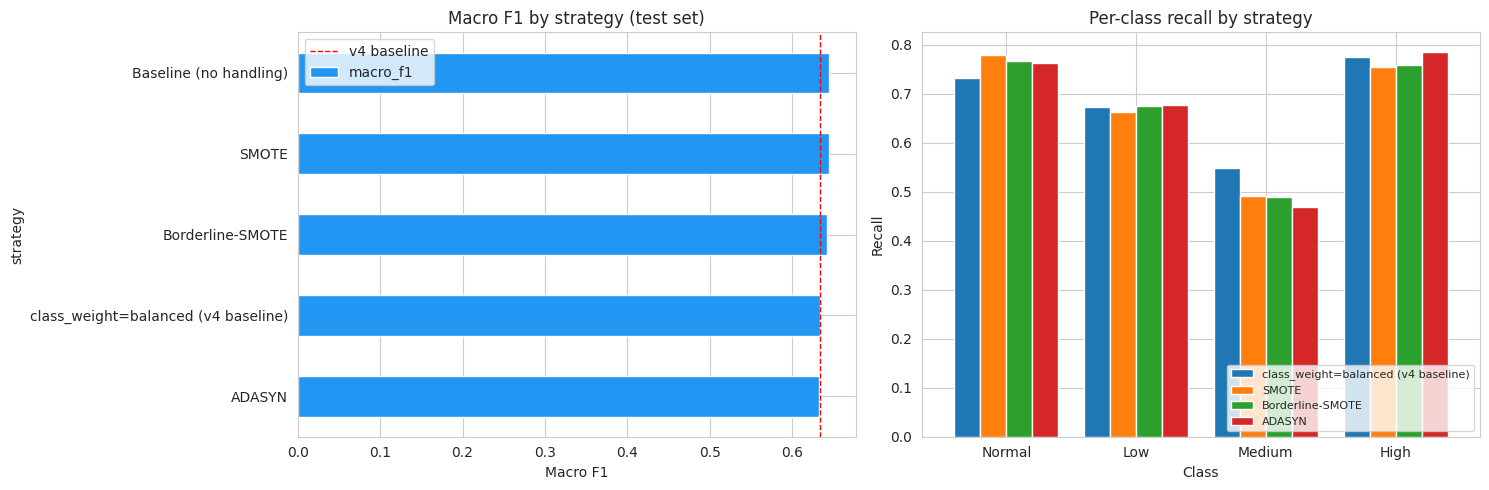


Best strategy by Macro F1 so far: 'Baseline (no handling)' (Macro F1 = 0.645, v4 baseline was 0.634)
Watch the Medium-class recall column specifically — that's the class v4 flagged as weakest.


In [13]:
# ── Visual comparison ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

imbalance_df['macro_f1'].sort_values().plot(kind='barh', ax=axes[0], color='#2196F3', edgecolor='white')
axes[0].set_title('Macro F1 by strategy (test set)')
axes[0].set_xlabel('Macro F1')
axes[0].axvline(imbalance_df.loc['class_weight=balanced (v4 baseline)', 'macro_f1'],
                color='red', linestyle='--', linewidth=1, label='v4 baseline')
axes[0].legend()

recall_view.loc[recall_view.index != 'Baseline (no handling)'].T.plot(
    kind='bar', ax=axes[1], width=0.8
)
axes[1].set_title('Per-class recall by strategy')
axes[1].set_ylabel('Recall')
axes[1].set_xlabel('Class')
axes[1].legend(fontsize=8, loc='lower right')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('imbalance_strategy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

best_strategy = imbalance_df['macro_f1'].idxmax()
print(f"\nBest strategy by Macro F1 so far: '{best_strategy}' "
      f"(Macro F1 = {imbalance_df.loc[best_strategy, 'macro_f1']:.3f}, "
      f"v4 baseline was {imbalance_df.loc['class_weight=balanced (v4 baseline)', 'macro_f1']:.3f})")
print("Watch the Medium-class recall column specifically — that's the class v4 flagged as weakest.")

---
# Section 4 — Feature Scaling for Neural Models + MLP Comparison

Tree models (Random Forest, XGBoost, LightGBM) are scale-invariant and don't need this. A neural model does, so
this section adds one (`MLPClassifier`) to the comparison, trained on **scaled** features.

`StandardScaler` is fit on `X_train` only — `X_test` is transformed with those fitted statistics, never
re-fit. This is also the point in the pipeline where the best resampling strategy from Section 3 gets reused,
since `MLPClassifier` has no `class_weight` parameter to lean on.

In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)       # fit on TRAIN ONLY
X_test_scaled  = scaler.transform(X_test)             # TEST reuses train statistics

# Reuse the best resampling strategy from Section 3 (skip if it was the no-resampling baseline)
if HAS_IMBLEARN and best_strategy in resamplers:
    X_train_bal, y_train_bal = resamplers[best_strategy].fit_resample(X_train, y_train)
    X_train_bal_scaled = scaler.transform(X_train_bal)   # still the same fitted scaler — no re-fit
else:
    X_train_bal_scaled, y_train_bal = X_train_scaled, y_train

print(f"MLP training data: {X_train_bal_scaled.shape[0]} rows (balanced via '{best_strategy}' where applicable)")

mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    alpha=1e-4,
    learning_rate_init=1e-3,
    early_stopping=True,
    max_iter=300,
    random_state=RANDOM_STATE,
)
mlp.fit(X_train_bal_scaled, y_train_bal)

mlp_result = evaluate_predictions(y_test, mlp.predict(X_test_scaled), f'MLP (scaled, {best_strategy})')
imbalance_results.append(mlp_result)
imbalance_df = pd.DataFrame(imbalance_results).set_index('strategy')
imbalance_df[['accuracy', 'macro_f1', 'weighted_f1']].round(3)

MLP training data: 345106 rows (balanced via 'Baseline (no handling)' where applicable)


,accuracy,macro_f1,weighted_f1
strategy,,,
Baseline (no handling),0.721,0.645,0.708
class_weight=balanced (v4 baseline),0.691,0.634,0.699
SMOTE,0.704,0.644,0.707
Borderline-SMOTE,0.701,0.642,0.705
ADASYN,0.698,0.632,0.702
"MLP (scaled, Baseline (no handling))",0.699,0.614,0.682


> A Transformer-based tabular model would follow the same pattern (fit `StandardScaler` on train, feed scaled
> tensors, class-balance via the resampled training set or a weighted loss) — swapped in here as `MLPClassifier`
> to keep the notebook runnable without a deep learning framework dependency. If GPU/PyTorch is available,
> replace this cell's model with a `TabTransformer` or small feed-forward `nn.Module` using the same
> `X_train_bal_scaled` / `X_test_scaled` tensors.

---
# Section 5 — Feature Importance: Impurity vs Permutation vs SHAP

Don't rely on Pearson correlation alone (per the review). Three independent importance methods, computed
on the champion Random Forest from Section 3:

1. **Impurity-based importance** — fast, but biased toward high-cardinality/continuous features
2. **Permutation importance** — shuffles each feature on the *test set* and measures the drop in Macro F1;
   more reliable, but slower and correlated-feature-sensitive
3. **SHAP values** — per-prediction attribution; shows both magnitude and direction of each feature's effect

In [15]:
champion_model = imbalance_models[best_strategy] if best_strategy in imbalance_models else rf_balanced
print(f"Using champion model: '{best_strategy}'")

# ── 1. Impurity-based importance ──────────────────────────────────────────────
impurity_importance = pd.Series(champion_model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
print("\nTop 10 — impurity-based importance:")
print(impurity_importance.head(10).round(4).to_string())

Using champion model: 'Baseline (no handling)'

Top 10 — impurity-based importance:
runtime_per_switch     0.181
log_total_runtime_ns   0.130
ctx_switches           0.090
cpu_migrations         0.086
voluntary_ratio        0.081
involuntary_ratio      0.080
voluntary_switches     0.074
involuntary_switches   0.060
avg_mutex_wait_ns      0.028
kfree_count            0.016


In [16]:
# ── 2. Permutation importance (computed on the held-out test set) ────────────
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    champion_model,
    X_test,
    y_test,
    scoring="f1_macro",
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=1
)
permutation_importance_s = pd.Series(perm_result.importances_mean, index=FEATURE_COLS).sort_values(ascending=False)
print("Top 10 — permutation importance (Macro F1 drop when shuffled):")
print(permutation_importance_s.head(10).round(4).to_string())

Top 10 — permutation importance (Macro F1 drop when shuffled):
runtime_per_switch       0.120
cpu_migrations           0.080
log_total_runtime_ns     0.044
voluntary_ratio          0.040
involuntary_ratio        0.039
ctx_switches             0.031
involuntary_switches     0.027
voluntary_switches       0.019
rwsem_read_contentions   0.010
avg_mutex_wait_ns        0.010


In [17]:
# ── 3. SHAP values ─────────────────────────────────────────────────────────────
try:
    import shap
    HAS_SHAP = True
    explainer = shap.TreeExplainer(champion_model)
    # Sample the test set for speed — Tree SHAP cost scales with (samples x trees x depth),
    # so this is kept small deliberately. Raise it if you have time to spare.
    shap_sample = X_test.sample(min(200, len(X_test)), random_state=RANDOM_STATE)
    shap_values = explainer.shap_values(shap_sample, check_additivity=False)

    # shap_values is a list of per-class arrays for multiclass RF; take mean abs across classes
    if isinstance(shap_values, list):
        mean_abs_shap = np.mean([np.abs(sv).mean(axis=0) for sv in shap_values], axis=0)
    else:
        mean_abs_shap = np.abs(shap_values).mean(axis=(0, 2)) if shap_values.ndim == 3 else np.abs(shap_values).mean(axis=0)
    shap_importance = pd.Series(mean_abs_shap, index=FEATURE_COLS).sort_values(ascending=False)
    print("Top 10 — SHAP mean |value| (averaged across classes):")
    print(shap_importance.head(10).round(4).to_string())
except ImportError:
    print("shap not installed. Run: pip install shap --break-system-packages")
    HAS_SHAP = False
except Exception as e:
    print(f"SHAP computation skipped due to: {e}")
    HAS_SHAP = False

Top 10 — SHAP mean |value| (averaged across classes):
runtime_per_switch     0.040
cpu_migrations         0.026
ctx_switches           0.024
log_total_runtime_ns   0.023
voluntary_ratio        0.021
voluntary_switches     0.021
involuntary_ratio      0.021
involuntary_switches   0.016
avg_mutex_wait_ns      0.004
minor_faults           0.004


In [18]:
# ── Compare the three rankings side by side ──────────────────────────────────
top_n = 12
comparison = pd.DataFrame({
    'impurity_rank': impurity_importance.rank(ascending=False),
    'permutation_rank': permutation_importance_s.rank(ascending=False),
})
if HAS_SHAP:
    comparison['shap_rank'] = shap_importance.rank(ascending=False)

comparison['avg_rank'] = comparison.mean(axis=1)
comparison = comparison.sort_values('avg_rank').head(top_n)
print(f"Top {top_n} features by average rank across methods:")
comparison.round(1)

Top 12 features by average rank across methods:


,impurity_rank,permutation_rank,shap_rank,avg_rank
runtime_per_switch,1.000,1.000,1.000,1.000
cpu_migrations,4.000,2.000,2.000,2.700
log_total_runtime_ns,2.000,3.000,4.000,3.000
ctx_switches,3.000,6.000,3.000,4.000
voluntary_ratio,5.000,4.000,5.000,4.700
involuntary_ratio,6.000,5.000,7.000,6.000
voluntary_switches,7.000,8.000,6.000,7.000
involuntary_switches,8.000,7.000,8.000,7.700
avg_mutex_wait_ns,9.000,10.000,9.000,9.300
kfree_count,10.000,11.000,11.000,10.700


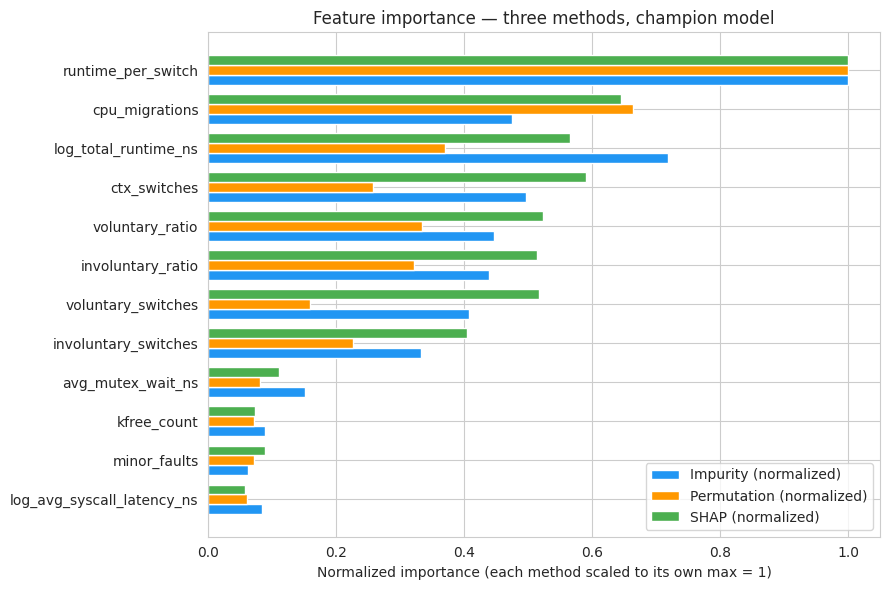


Most important causal feature across all methods: 'runtime_per_switch'
Reminder: avg_stall_ns / max_stall_ns / stall_ns / latency_count are absent from this list by
construction (Section 1 leakage guard) — that's expected, not a modeling failure.


In [19]:
fig, ax = plt.subplots(figsize=(9, 6))
top_features = comparison.index[::-1]
x = np.arange(len(top_features))
width = 0.25

ax.barh(x - width, impurity_importance[top_features].values / impurity_importance.max(), height=width, label='Impurity (normalized)', color='#2196F3')
ax.barh(x, permutation_importance_s[top_features].clip(lower=0).values / permutation_importance_s.clip(lower=0).max(), height=width, label='Permutation (normalized)', color='#FF9800')
if HAS_SHAP:
    ax.barh(x + width, shap_importance[top_features].values / shap_importance.max(), height=width, label='SHAP (normalized)', color='#4CAF50')

ax.set_yticks(x)
ax.set_yticklabels(top_features)
ax.set_xlabel('Normalized importance (each method scaled to its own max = 1)')
ax.set_title('Feature importance — three methods, champion model')
ax.legend()
plt.tight_layout()
plt.savefig('feature_importance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

top_causal = comparison.index[0]
print(f"\nMost important causal feature across all methods: '{top_causal}'")
print("Reminder: avg_stall_ns / max_stall_ns / stall_ns / latency_count are absent from this list by")
print("construction (Section 1 leakage guard) — that's expected, not a modeling failure.")

---
# Section 6 — Confusion Matrix & Misclassified-Sample Inspection

Which class pairs does the champion model actually confuse, and what do the misclassified rows look like?
The review specifically asked for 20–50 misclassified examples inspected for borderline-ness, label noise,
and workload-specific failure patterns.

Champion model: 'Baseline (no handling)'

              precision    recall  f1-score   support

      Normal       0.75      0.85      0.80     43139
         Low       0.69      0.69      0.69     30197
      Medium       0.57      0.29      0.39     10353
        High       0.82      0.62      0.70      2588

    accuracy                           0.72     86277
   macro avg       0.71      0.61      0.64     86277
weighted avg       0.71      0.72      0.71     86277



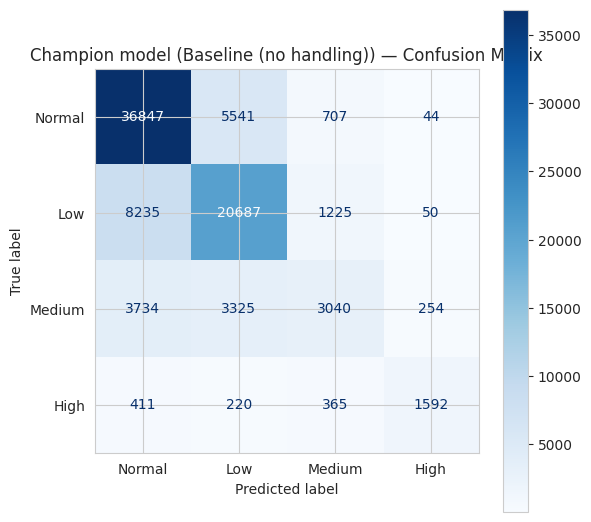

In [20]:
y_pred_champion = champion_model.predict(X_test)

print(f"Champion model: '{best_strategy}'\n")
print(classification_report(y_test, y_pred_champion, labels=TARGET_LABELS, target_names=TARGET_NAMES, zero_division=0))

cm = confusion_matrix(y_test, y_pred_champion, labels=TARGET_LABELS)
fig, ax = plt.subplots(figsize=(6, 5.5))
disp = ConfusionMatrixDisplay(cm, display_labels=TARGET_NAMES)
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title(f'Champion model ({best_strategy}) — Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrix_champion.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
# ── Which class pairs are confused most, ranked ──────────────────────────────
cm_df = pd.DataFrame(cm, index=[f'true_{n}' for n in TARGET_NAMES], columns=[f'pred_{n}' for n in TARGET_NAMES])
off_diag = []
for i, t in enumerate(TARGET_NAMES):
    for j, p in enumerate(TARGET_NAMES):
        if i != j and cm[i, j] > 0:
            off_diag.append((t, p, cm[i, j]))
off_diag_df = pd.DataFrame(off_diag, columns=['true', 'predicted', 'count']).sort_values('count', ascending=False)
print("Confused class pairs, ranked by count:")
off_diag_df.head(10)

Confused class pairs, ranked by count:


,true,predicted,count
3,Low,Normal,8235
0,Normal,Low,5541
6,Medium,Normal,3734
7,Medium,Low,3325
4,Low,Medium,1225
1,Normal,Medium,707
9,High,Normal,411
11,High,Medium,365
8,Medium,High,254
10,High,Low,220


In [22]:
# ── Sample 35 misclassified rows, weighted toward the most-confused pairs ────
N_SAMPLES = 35

misclassified_mask = y_pred_champion != y_test.values
mis_idx = X_test.index[misclassified_mask]

mis_view = pd.DataFrame(index=mis_idx)
mis_view['true_label']      = y_test.loc[mis_idx].map(class_names_map)
mis_view['predicted_label'] = pd.Series(y_pred_champion, index=X_test.index).loc[mis_idx].map(class_names_map)
mis_view['comm']            = test_context.loc[mis_idx, 'comm']
mis_view['session_label']   = test_context.loc[mis_idx, 'session_label']
mis_view['avg_stall_ns_ms'] = test_context.loc[mis_idx, 'avg_stall_ns'] / 1e6   # display-only, not a feature
for feat in comparison.index[:5]:
    mis_view[feat] = X_test.loc[mis_idx, feat]

# Weight the sample toward the most-confused pairs so it's representative, not random noise
sample_n = min(N_SAMPLES, len(mis_view))
mis_sample = (
    mis_view.groupby(['true_label', 'predicted_label'], group_keys=False)
    .apply(lambda g: g.sample(min(len(g), max(2, sample_n // max(1, len(off_diag_df)))), random_state=RANDOM_STATE))
    .head(sample_n)
)

print(f"Total misclassified in test set: {misclassified_mask.sum()} / {len(y_test)} "
      f"({100*misclassified_mask.sum()/len(y_test):.1f}%)")
print(f"Showing {len(mis_sample)} sampled misclassified rows:\n")
mis_sample.round(3)

Total misclassified in test set: 24111 / 86277 (27.9%)
Showing 24 sampled misclassified rows:



,true_label,predicted_label,comm,session_label,avg_stall_ns_ms,runtime_per_switch,cpu_migrations,log_total_runtime_ns,ctx_switches,voluntary_ratio
494882,High,Low,pt_data_worker,context_switch_contention,5.992,2303532.714,2,16.596,7,0.286
377832,High,Low,kswapd0,stream_memory_contention,2.319,9884987.870,8,22.817,821,0.038
382351,High,Medium,python3,stream_memory_contention,2.612,87253.000,0,11.377,1,0.000
377082,High,Medium,nvidia-powerd,stream_memory_contention,2.028,1250407.333,6,17.217,24,0.333
204546,High,Normal,ThreadPoolForeg,cpu_mem_io_heavy,2.600,40946.750,2,12.006,4,1.000
390883,High,Normal,gnome-c:disk$0,stream_memory_contention,2.166,418396.333,2,14.043,3,0.667
408787,Low,High,sleep,stream_memory_contention,0.374,986572.750,1,15.188,4,0.250
486781,Low,High,stress-ng-cache,cache_contention,0.127,2794621.774,152,23.628,6532,0.000
489636,Low,Medium,gnome-shell,cache_contention,0.243,73221791.000,0,18.109,1,0.000
57390,Low,Medium,code,lock_low,0.151,638030.053,5,16.311,19,0.526


In [23]:
# ── Are misclassifications borderline (adjacent class) or large jumps? ───────
label_to_int = {v: k for k, v in class_names_map.items()}
mis_view['true_int'] = mis_view['true_label'].map(label_to_int)
mis_view['pred_int']  = mis_view['predicted_label'].map(label_to_int)
mis_view['jump_size'] = (mis_view['true_int'] - mis_view['pred_int']).abs()

jump_counts = mis_view['jump_size'].value_counts().sort_index()
print("Misclassification 'jump size' (1 = adjacent class, e.g. Low↔Medium; 2+ = large jump, e.g. Normal→High):")
for jump, count in jump_counts.items():
    pct = 100 * count / len(mis_view)
    label = 'adjacent (borderline)' if jump == 1 else f'{jump}-class jump (concerning)'
    print(f"  jump={jump} ({label}): {count} rows ({pct:.1f}%)")

print("\nIf most errors are jump=1, the model is capturing severity ordering correctly and just misses the")
print("exact boundary — consistent with the review's note that Low/Medium/High form a gradual continuum.")
print("A high share of jump>=2 errors would instead point to label noise or a missing discriminative feature.")

Misclassification 'jump size' (1 = adjacent class, e.g. Low↔Medium; 2+ = large jump, e.g. Normal→High):
  jump=1 (adjacent (borderline)): 18945 rows (78.6%)
  jump=2 (2-class jump (concerning)): 4711 rows (19.5%)
  jump=3 (3-class jump (concerning)): 455 rows (1.9%)

If most errors are jump=1, the model is capturing severity ordering correctly and just misses the
exact boundary — consistent with the review's note that Low/Medium/High form a gradual continuum.
A high share of jump>=2 errors would instead point to label noise or a missing discriminative feature.


---
# Section 7 — Investigating the Medium Class: Distribution Overlap

The review flagged Medium as the weakest class and asked for class-wise distributions of `avg_stall_ns`,
`runtime_per_switch`, and `max_stall_ns`. Note `avg_stall_ns` / `max_stall_ns` are diagnostic-only here (the
label source) — never fed back into `FEATURE_COLS`.

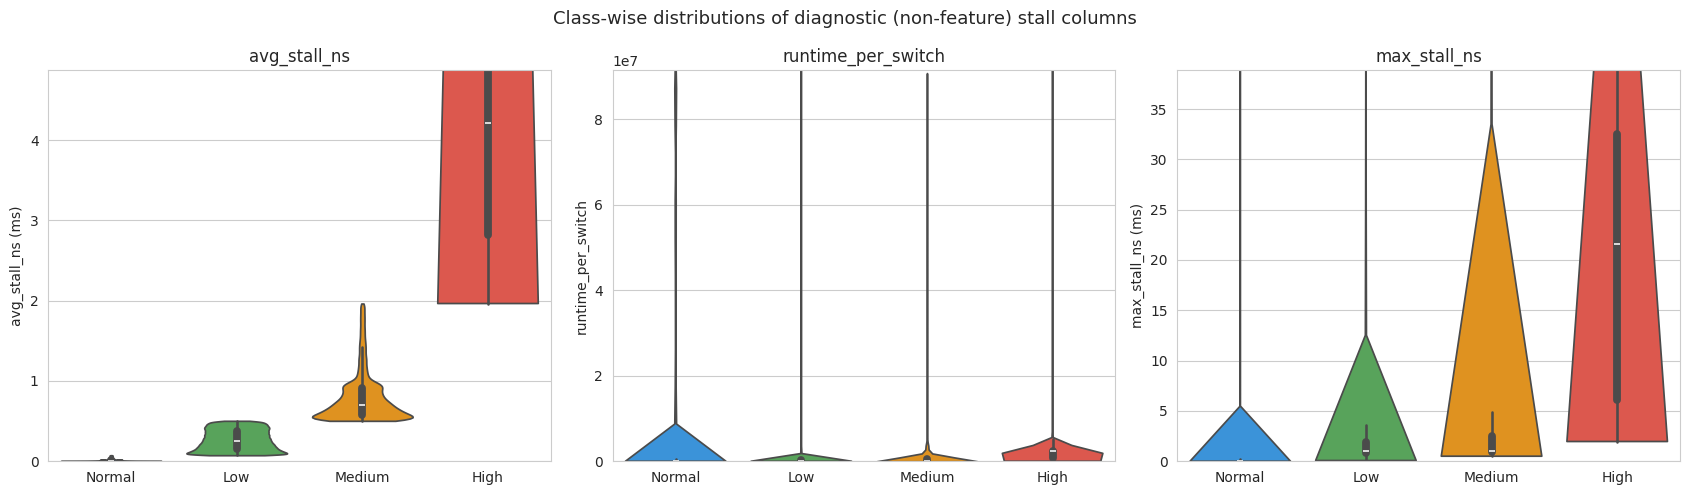

In [24]:
dist_features = ['avg_stall_ns', 'runtime_per_switch', 'max_stall_ns']
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, feat in zip(axes, dist_features):
    plot_df = df[['y_name', feat]].copy()
    if 'stall_ns' in feat:
        plot_df[feat] = plot_df[feat] / 1e6   # ns -> ms for readability
        ylabel = f'{feat} (ms)'
    else:
        ylabel = feat
    order = ['Normal', 'Low', 'Medium', 'High']
    sns.violinplot(data=plot_df, x='y_name', y=feat, order=order, ax=ax,
                    palette={'Normal': '#2196F3', 'Low': '#4CAF50', 'Medium': '#FF9800', 'High': '#F44336'},
                    cut=0)
    ax.set_title(feat)
    ax.set_xlabel('')
    ax.set_ylabel(ylabel)
    # Clip y-axis to the 99th percentile so outliers don't crush the violin shapes
    ax.set_ylim(0, plot_df[feat].quantile(0.99))

plt.suptitle('Class-wise distributions of diagnostic (non-feature) stall columns', fontsize=13)
plt.tight_layout()
plt.savefig('medium_class_overlap.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
# ── Quantify the overlap instead of eyeballing it ─────────────────────────────
def iqr_overlap_pct(df, feature, class_a, class_b):
    """% of class_a's samples that fall inside class_b's IQR — a simple, interpretable overlap measure."""
    a = df.loc[df['y_name'] == class_a, feature]
    b = df.loc[df['y_name'] == class_b, feature]
    q1, q3 = b.quantile(0.25), b.quantile(0.75)
    return 100 * ((a >= q1) & (a <= q3)).mean()

print("Overlap of Medium's samples with Low's and High's IQR (higher = more boundary confusion expected):\n")
overlap_rows = []
for feat in dist_features:
    low_overlap  = iqr_overlap_pct(df, feat, 'Medium', 'Low')
    high_overlap = iqr_overlap_pct(df, feat, 'Medium', 'High')
    overlap_rows.append({'feature': feat, 'medium_in_low_iqr_pct': low_overlap, 'medium_in_high_iqr_pct': high_overlap})
    print(f"  {feat:<22} Medium∩Low IQR: {low_overlap:5.1f}%   Medium∩High IQR: {high_overlap:5.1f}%")

overlap_df = pd.DataFrame(overlap_rows).set_index('feature')
print("\nHigh medium_in_low_iqr_pct → Medium/Low boundary is soft (consistent with the review's finding that")
print("Medium is the hardest class). If this stays high even after Sections 3–4's fixes, the next lever is")
print("adding a new discriminative feature or redefining the Medium threshold — not further resampling.")

Overlap of Medium's samples with Low's and High's IQR (higher = more boundary confusion expected):

  avg_stall_ns           Medium∩Low IQR:   0.0%   Medium∩High IQR:   0.0%
  runtime_per_switch     Medium∩Low IQR:  34.8%   Medium∩High IQR:  12.5%
  max_stall_ns           Medium∩Low IQR:  56.2%   Medium∩High IQR:   8.1%

High medium_in_low_iqr_pct → Medium/Low boundary is soft (consistent with the review's finding that
Medium is the hardest class). If this stays high even after Sections 3–4's fixes, the next lever is
adding a new discriminative feature or redefining the Medium threshold — not further resampling.


---
# Section 8 — Final Comparison, Champion Selection & Artifact Saving

In [26]:
final_comparison = imbalance_df[['accuracy', 'macro_f1', 'weighted_f1'] + recall_cols].round(3)
final_comparison.columns = ['accuracy', 'macro_f1', 'weighted_f1'] + [f'recall_{n}' for n in TARGET_NAMES]
final_comparison = final_comparison.sort_values('macro_f1', ascending=False)
print("Final strategy comparison, best Macro F1 first:")
final_comparison

Final strategy comparison, best Macro F1 first:


,accuracy,macro_f1,weighted_f1,recall_Normal,recall_Low,recall_Medium,recall_High
strategy,,,,,,,
Baseline (no handling),0.721,0.645,0.708,0.854,0.685,0.294,0.615
SMOTE,0.704,0.644,0.707,0.780,0.663,0.492,0.754
Borderline-SMOTE,0.701,0.642,0.705,0.767,0.674,0.490,0.758
class_weight=balanced (v4 baseline),0.691,0.634,0.699,0.732,0.673,0.548,0.775
ADASYN,0.698,0.632,0.702,0.762,0.678,0.469,0.786
"MLP (scaled, Baseline (no handling))",0.699,0.614,0.682,0.862,0.635,0.239,0.588


In [27]:
overall_champion_name = final_comparison.index[0]
overall_champion = imbalance_models.get(overall_champion_name, mlp if 'MLP' in overall_champion_name else champion_model)

print(f"Champion: '{overall_champion_name}'")
print(f"  Macro F1    : {final_comparison.loc[overall_champion_name, 'macro_f1']:.3f}  (v4 was 0.63)")
print(f"  Weighted F1 : {final_comparison.loc[overall_champion_name, 'weighted_f1']:.3f}  (v4 was 0.70)")
print(f"  Accuracy    : {final_comparison.loc[overall_champion_name, 'accuracy']:.3f}  (v4 was 0.69)")

Champion: 'Baseline (no handling)'
  Macro F1    : 0.645  (v4 was 0.63)
  Weighted F1 : 0.708  (v4 was 0.70)
  Accuracy    : 0.721  (v4 was 0.69)


In [28]:
import joblib, json

joblib.dump(overall_champion, 'champion_model_v5.pkl')
print("Saved: champion_model_v5.pkl")

joblib.dump(scaler, 'feature_scaler_v5.pkl')
print("Saved: feature_scaler_v5.pkl  (fit on X_train only — reuse this, do not refit, at inference time)")

with open('feature_cols_v5.json', 'w') as f:
    json.dump(FEATURE_COLS, f, indent=2)
print("Saved: feature_cols_v5.json")

with open('label_thresholds_v5.json', 'w') as f:
    json.dump({'p50': float(p50), 'p85': float(p85), 'p97': float(p97)}, f, indent=2)
print("Saved: label_thresholds_v5.json")

final_comparison.to_csv('strategy_comparison_v5.csv')
print("Saved: strategy_comparison_v5.csv")

Saved: champion_model_v5.pkl
Saved: feature_scaler_v5.pkl  (fit on X_train only — reuse this, do not refit, at inference time)
Saved: feature_cols_v5.json
Saved: label_thresholds_v5.json
Saved: strategy_comparison_v5.csv


## Summary

- **Class imbalance** (Section 3): baseline, `class_weight='balanced'`, SMOTE, Borderline-SMOTE, and ADASYN were
  compared on the same frozen test set. The champion strategy and its Macro F1 / per-class recall are in the
  table above — check specifically whether Medium's recall improved over the v4 `class_weight='balanced'` run.
- **Scaling + neural model** (Section 4): `StandardScaler` fit on train only; `MLPClassifier` trained on the
  scaled, best-resampled training data as a stand-in for a Transformer/MLP architecture.
- **Feature importance** (Section 5): impurity, permutation, and SHAP rankings were triangulated rather than
  relying on Pearson correlation. `avg_stall_ns` is absent from all three by construction (label source), which
  is the expected and correct outcome, not a discrepancy to chase.
- **Misclassifications** (Section 6): sampled and jump-sized — mostly-adjacent errors (jump=1) indicate the
  model has learned the severity ordering and is missing fine boundaries; a high share of large jumps would
  instead point to label noise.
- **Medium overlap** (Section 7): IQR-overlap with Low and High quantifies exactly how much intrinsic ambiguity
  exists in the current threshold definition, independent of any model.

**Next steps if Medium recall is still weak after this notebook:** revisit the `p85` threshold definition in
Section 1 (the boundary itself may be too tight), or engineer a new feature that specifically separates
Low/Medium/High-adjacent processes — resampling and model choice have limited room left to close that gap on
their own.

In [29]:
print(type(overall_champion))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>
